# Esercizio 4

In [32]:
# ── Librerie base ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualizzazione ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Econometria / Statistica ───────────────────────────────────────────────────
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.regression.rolling import RollingOLS
from statsmodels.datasets import longley
from statsmodels.iolib.summary2 import summary_col
from statsmodels.tsa.stattools import adfuller

from scipy import stats
from scipy.stats import norm, linregress

# ── Machine Learning / PCA / Clustering ───────────────────────────────────────
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# ── Ottimizzazione portafoglio ─────────────────────────────────────────────────
from pypfopt import EfficientFrontier
from pypfopt import risk_models
from pypfopt import expected_returns

# ── Dati finanziari ────────────────────────────────────────────────────────────
import yfinance as yf
import fmfinance as fm
import financedatabase as fd
import quantstats as qs

# ── Calcolo parallelo ──────────────────────────────────────────────────────────
from joblib import Parallel, delayed

# ── Interfaccia R ──────────────────────────────────────────────────────────────
import rpy2.robjects as ro
from rpy2.robjects.packages import importr

# ── Trading algoritmico (Alpaca) ───────────────────────────────────────────────
from alpaca.trading.client import TradingClient
from alpaca.trading.requests import MarketOrderRequest, LimitOrderRequest, ClosePositionRequest
from alpaca.trading.enums import OrderSide, TimeInForce
from alpaca.data.historical import StockHistoricalDataClient
from alpaca.data.requests import StockLatestTradeRequest, StockLatestQuoteRequest

# ── Web scraping ───────────────────────────────────────────────────────────────
import requests
from bs4 import BeautifulSoup
from io import StringIO

# ── UI interattiva ─────────────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display

# ── Utility ────────────────────────────────────────────────────────────────────
from datetime import datetime
from pandas.plotting import register_matplotlib_converters
import random
import time
import os
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

---
## PUNTO 1

In [33]:
tickers=['GME', 'AMC', 'BB', 'NOK' ,'^RUT']

start = '2014-01-01'
end = '2025-12-31'

prices = yf.download(tickers, start, end, auto_adjust=False, multi_level_index=False, progress=False, interval='1mo')['Adj Close']
prices

Ticker,AMC,BB,GME,NOK,^RUT
Date,,,,,
2014-01-01,153.699051,9.45,6.316032,4.928852,1130.880005
2014-02-01,164.631332,10.00,6.719452,5.398945,1183.030029
2014-03-01,174.412827,8.08,7.402022,5.228002,1173.040039
2014-04-01,166.429382,7.66,7.208068,5.341963,1126.859985
2014-05-01,163.049026,7.60,6.875638,5.790689,1134.500000
...,...,...,...,...,...
2025-08-01,2.810000,3.83,22.410000,4.300000,2366.419922
2025-09-01,2.900000,4.88,27.280001,4.810000,2436.479980
2025-10-01,2.590000,4.88,22.290001,6.910000,2479.379883


La tabella mostra i prezzi adjusted close mensili scaricati da Yahoo Finance per le quattro meme stocks (GME, AMC, BB, NOK) e il benchmark Russell 2000 (^RUT) nel periodo gennaio 2014 – dicembre 2025, per un totale di 144 osservazioni mensili.

In [34]:
ratio = prices.copy()
ratio = (ratio / ratio.iloc[0]) * 100
ratio = ratio[['GME','AMC','BB','NOK']].divide(ratio['^RUT'], axis=0)
ratio

Ticker,GME,AMC,BB,NOK
Date,,,,
2014-01-01,1.000000,1.000000,1.000000,1.000000
2014-02-01,1.016975,1.023911,1.011554,1.047090
2014-03-01,1.129821,1.093984,0.824296,1.022571
2014-04-01,1.145305,1.086689,0.813474,1.087681
2014-05-01,1.085127,1.057448,0.801667,1.171107
...,...,...,...,...
2025-08-01,1.695595,0.008737,0.193683,0.416915
2025-09-01,2.004720,0.008758,0.239685,0.452953
2025-10-01,1.609679,0.007686,0.235538,0.639449


I prezzi vengono prima normalizzati a base 100 dalla prima osservazione disponibile, poi viene costruito il ratio dividendo il prezzo normalizzato di ciascun titolo per quello del Russell 2000. Un valore pari a 1 indica che il titolo si muove esattamente in linea con l'indice. Valori superiori a 1 indicano sovraperformance relativa, valori inferiori sottoperformance.

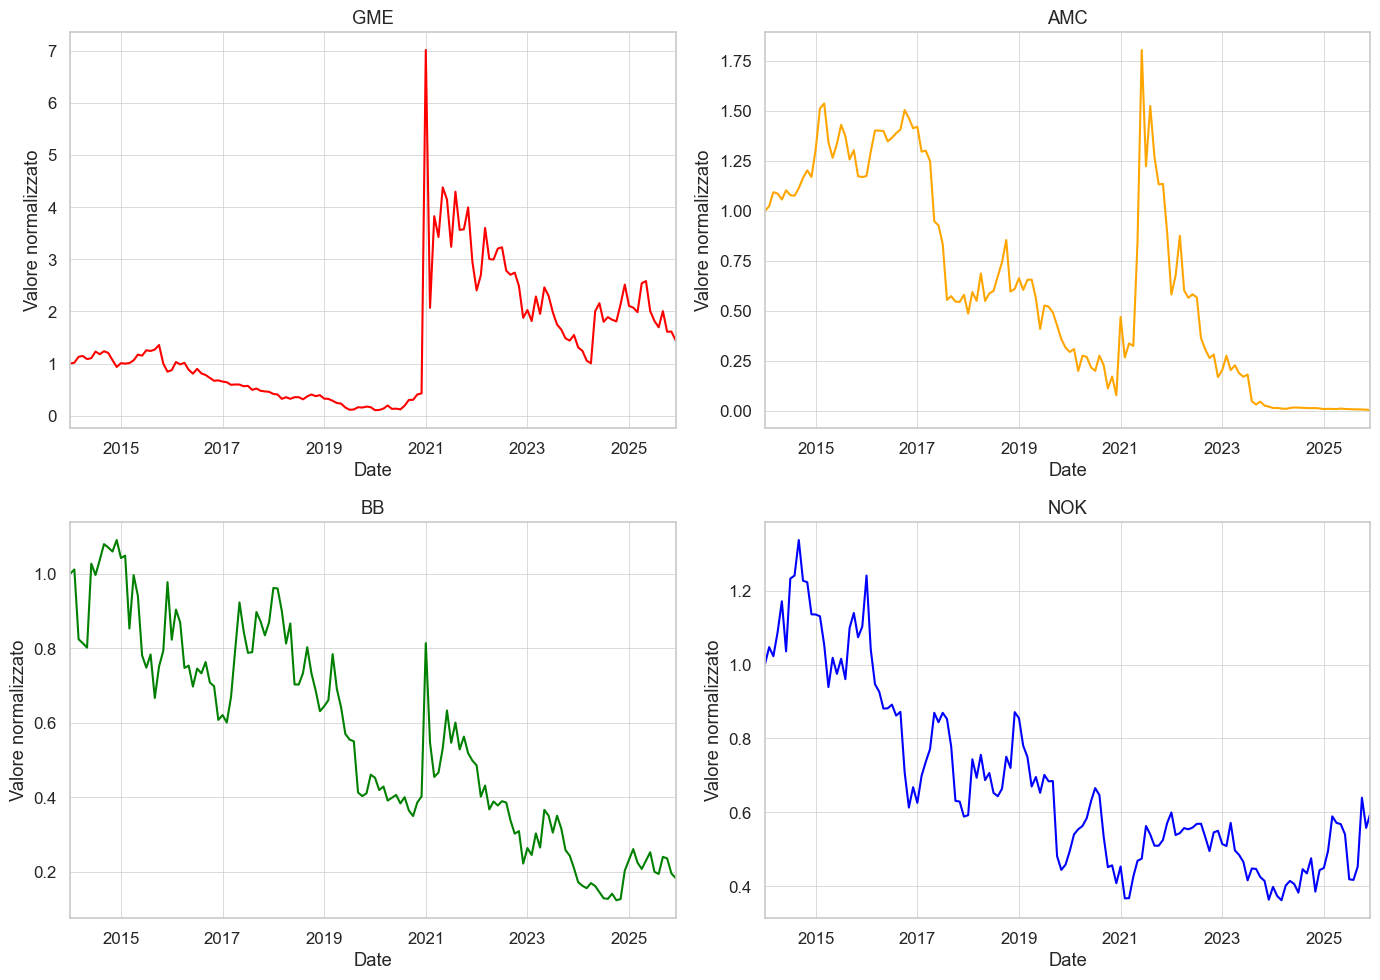

In [35]:
# plottiamo il ratio normalizzato di ciascun titolo rispetto al russell2000
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['red', 'orange', 'green', 'blue']

for i, col in enumerate(ratio.columns):
    ax = axes[i]
    ratio[col].plot(ax=ax, color=colors[i])
    ax.set_title(f'{col}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Valore normalizzato')
    ax.grid(True)

plt.tight_layout()
plt.show()

Il grafico mostra l'andamento del rapporto tra il prezzo normalizzato di ciascuna meme stock e il Russell 2000, anch'esso normalizzato. Un valore superiore a 1 indica che il titolo sta sovraperformando l'indice, un valore inferiore che lo sta sottoperformando.

**GME** mostra il picco più evidente: nella prima metà del 2021 il ratio schizza a circa 7, segnale di un'impennata esplosiva rispetto al mercato, seguita da un crollo rapido. È il caso più classico di meme stock con comportamento esplosivo.

**AMC** presenta un andamento simile ma meno estremo, un primo periodo di sovraperformance relativa intorno al 2015-2016, poi un picco nel 2021 anch'esso seguito da un collasso prolungato fino a quasi zero.

**BB** e **NOK** non mostrano picchi paragonabili; i loro ratio presentano una tendenza decrescente per tutto il periodo.

---
## PUNTO 2

In [36]:
# Calcolo della sequenza BSADF
multicore = True

bsadf_results = {}

for col in ratio.columns:
    series = ratio[col].dropna()
    n = len(series)
    min_w = int(np.ceil((0.01 + 1.8/np.sqrt(n)) * n))
    
    def compute_bsadf(r2):
        return np.nanmax([
            adfuller(series[r1:r2], regression='c', autolag='BIC', maxlag=4)[0]
            for r1 in range(0, r2 - min_w + 1)
        ])
    
    if multicore:
        bsadfs = Parallel(n_jobs=-1)(delayed(compute_bsadf)(r2) for r2 in range(min_w, n + 1))
    else:
        bsadfs = [compute_bsadf(r2) for r2 in range(min_w, n + 1)]
    
    bsadf_results[col] = pd.DataFrame(bsadfs).set_index(series.iloc[min_w-1:].index)

In [37]:
# Calcolo del valore critico SADF (buona approssimazione del BSADF)
np.random.seed(12345)
J = 10000
n = 144
min_w = int(np.ceil((0.01 + 1.8 / np.sqrt(n)) * n))
alpha = 0
phi = 1
multicore = True

seeds = np.random.randint(0, 1000000, size=J)

def sim_sadf(seed):
    np.random.seed(seed)
    epsilon = np.random.randn(n).reshape(n, -1)
    y = []
    y.append(alpha + epsilon[0])
    for t in range(1, n):
        y.append(alpha + phi * y[t-1] + epsilon[t])
    y = pd.DataFrame(y)
    return np.nanmax([adfuller(y[:k+1], regression='c', autolag=None, maxlag=0)[0] for k in range(min_w, n)])

if multicore:
    SADF_cv = Parallel(n_jobs=-1)(delayed(sim_sadf)(s) for s in seeds)
else:
    SADF_cv = [sim_sadf(s) for s in seeds]

In [38]:
# Stampiamo i valori critici
SADF_Constant=pd.DataFrame([(np.percentile(SADF_cv, 90)), (np.percentile(SADF_cv, 95)), (np.percentile(SADF_cv, 99))])

SADF_Results=SADF_Constant
SADF_Results.columns=['Constant']
SADF_Results.index=['90','95','99']
SADF_Results

,Constant
90,1.019558
95,1.318454
99,1.928552


In [39]:
# Il GSADF di ogni titolo è il massimo della sequenza BSADF sull'intero campione
# Se supera il valore critico al 95%, si rifiuta H0 -> evidenza di bolla
gsadf = pd.concat(bsadf_results, axis=1)
gsadf.columns = gsadf.columns.get_level_values(0)
gsadf.max()

GME    3.788957
AMC    1.910355
BB     1.465126
NOK    0.932029
dtype: float64

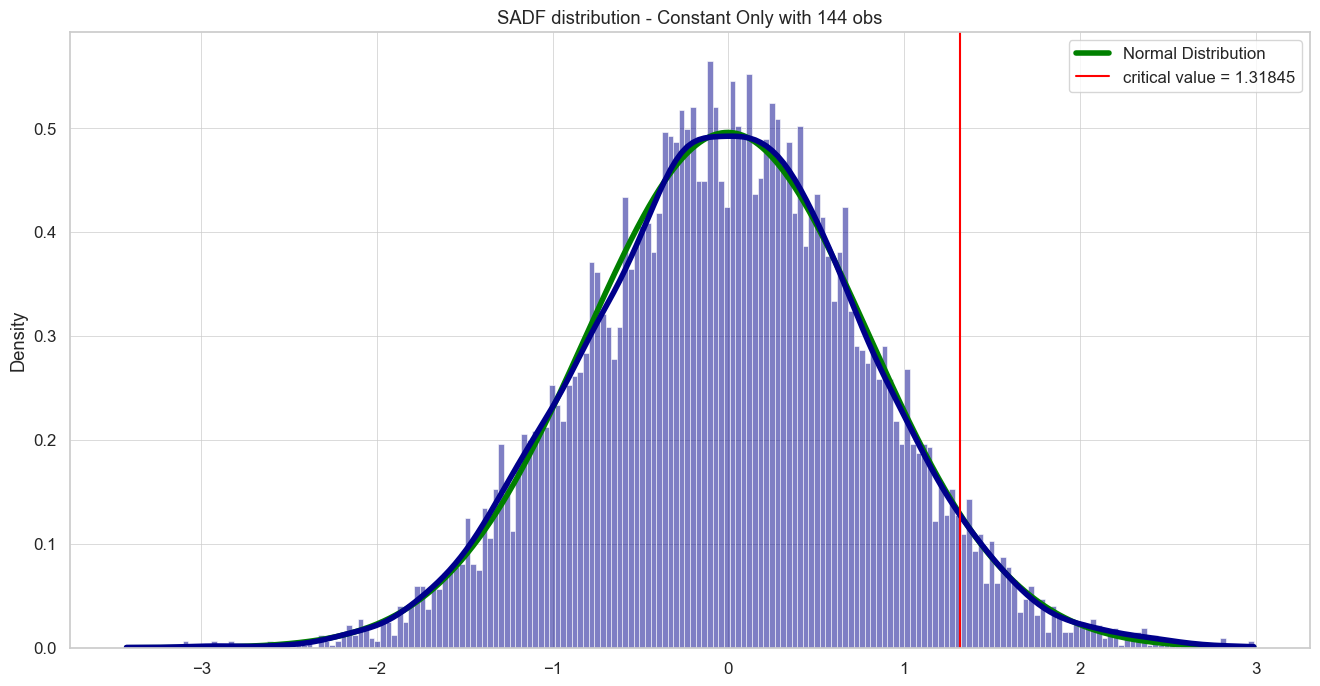

In [40]:
# Costruiamo la distribuzione dei valori critici del test SADF sotto l'ipotesi nulla di random walk
sns.set_style('whitegrid')
plt.figure(figsize=(16,8))
plt.title('SADF distribution - Constant Only with {} obs'.format(n))
x_axis = np.arange(min(SADF_cv), max(SADF_cv),0.001)


mean = np.mean(SADF_cv)
std = np.std(SADF_cv)
normal_dist = norm.pdf(x_axis, mean, std)
plt.plot(x_axis, normal_dist, color='green', linewidth=4, label='Normal Distribution')



sns.histplot(sorted(SADF_cv), kde=True, 
             bins=200, color = 'darkblue', 
             cbar_kws={'edgecolor':'black'},
             line_kws={'linewidth': 4},stat='density')
plt.axvline(SADF_Results.iloc[1,0], color='red',label='critical value = {}'.format(np.round((SADF_Results.iloc[1,0]),5)))
plt.legend()
plt.show()

Il grafico mostra la distribuzione empirica della statistica SADF ottenuta simulando 10.000 random walk sotto l'ipotesi nulla di assenza di bolla. La distribuzione è approssimativamente normale, come evidenziato dal confronto con la curva gaussiana verde.

La linea rossa verticale indica il valore critico al 95% (1.318): un valore SADF osservato sui dati reali che supera questa soglia permette di rifiutare H0 e concludere che la serie presenta comportamento esplosivo, ovvero evidenza di bolla.

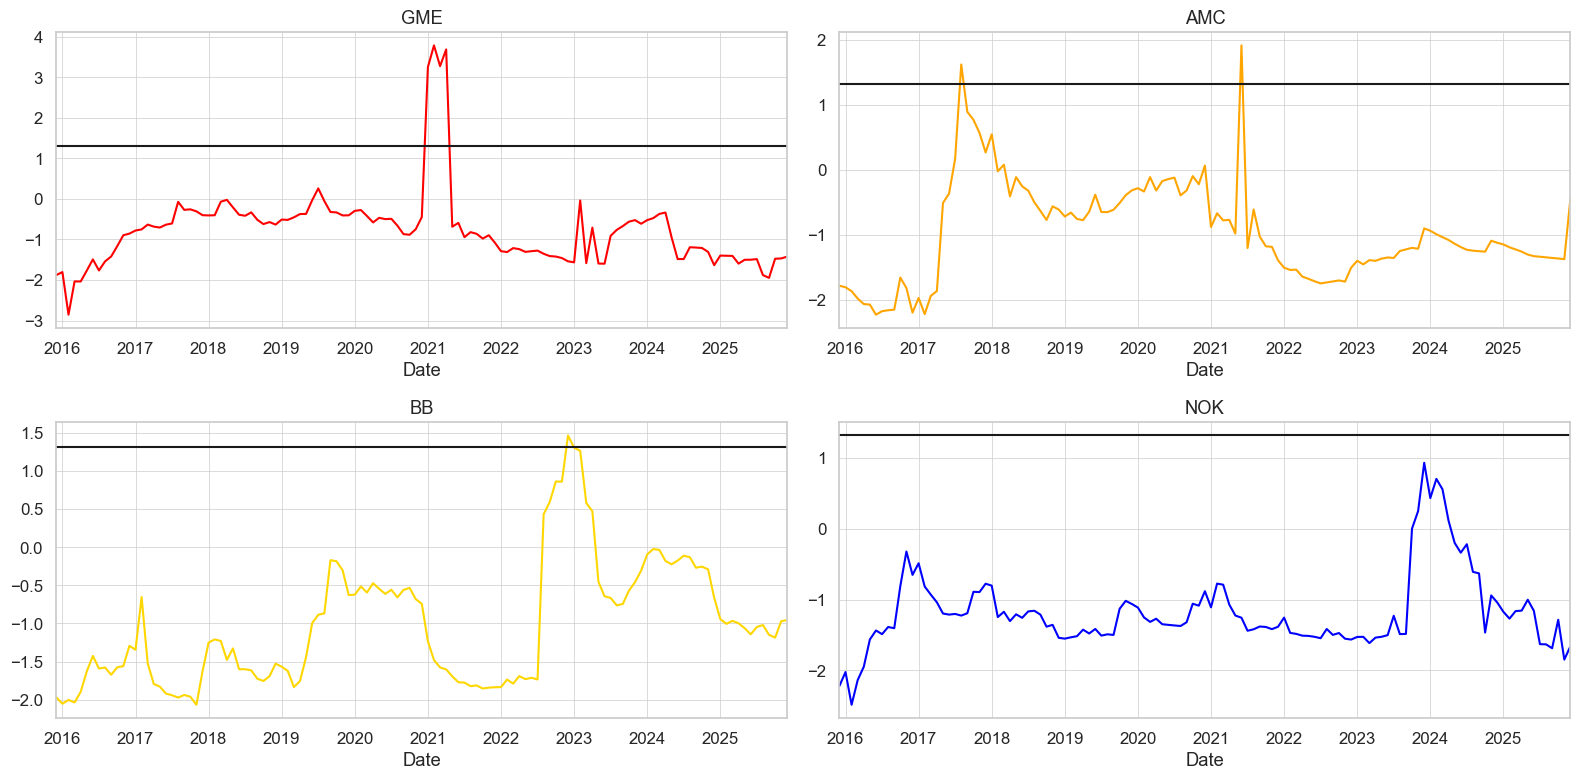

In [41]:
# Grafici BSADF per ogni titolo con valore critico al 95% (linea nera)
# Quando la sequenza supera la soglia c'è evidenza di comportamento esplosivo
cv_map = {'GME': 1.318, 'AMC': 1.318, 'BB': 1.318, 'NOK': 1.318}

fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
colors = ['red', 'orange', 'gold', 'blue', 'pink', 'green', 'purple']

for i in range(len(ratio.columns)):
    col = ratio.columns[i]
    ax = axes[i]
    bsadf_results[col].plot(ax=ax, color=colors[i], legend=False)
    ax.axhline(y=cv_map[col], color='k')
    ax.set_title(col)
    ax.grid(True)


plt.tight_layout()
plt.show()

Quando la sequenza BSADF dei 4 titoli rompe la linea orizzontale significa che in quel momento la serie storica del ratio prezzo/indice ha un comportamento esplosivo. Il test sta dicendo che in quel momento c'è evidenza statistica di una bolla speculativa. Il momento in cui rompe verso l'alto è la data di inizio della bolla, il momento in cui torna sotto è la data di fine.

Il test GSADF è un test globale. Risponde alla domanda nel periodo 2014 - 2025, c'è stata almeno una bolla in questo titolo? Viene confrontato con il valore critico pari a 1.318. Se GSADF > 1.318 si rifiuta l'ipotesi nulla di nessuna bolla. Evidenzia almeno un episodio esplosivo di bolla. Se GSADF è minore di 1.318 non si rifiuta l'ipotesi nulla. Nessuna evidenza di bolla (come Nokia con 0.932). Graficamente il GSADF di ogni titolo è il picco massimo di ogni grafico; è quindi il punto più alto toccato lla sequenza BSADF in tutto il periodo e se quel picco supera la linea nera c'è evidenza di bolla.

In [42]:
# Con questo blocco indichiamo i periodi in cui è stata rilevata la presenza di una bolla per ogni azienda
print("=== DATE STAMPING (BSADF > CV 95%) ===\n")

for col in ratio.columns:
    bsadf = bsadf_results[col].iloc[:, 0]
    cv = cv_map[col]
    
    bubble = bsadf > cv
    starts = bsadf.index[bubble & ~bubble.shift(1, fill_value=False)]
    ends = bsadf.index[~bubble & bubble.shift(1, fill_value=False)]
    
    print(f"{col}:")
    for i in range(min(len(starts), len(ends))):
        print(f"  {starts[i].strftime('%Y-%m')}  -->  {ends[i].strftime('%Y-%m')}")
    if len(starts) > len(ends):
        print(f"  {starts[-1].strftime('%Y-%m')}  -->  in corso")
    if len(starts) == 0:
        print("  Nessun episodio")
    print()

=== DATE STAMPING (BSADF > CV 95%) ===

GME:
  2021-01  -->  2021-05

AMC:
  2017-08  -->  2017-09
  2021-06  -->  2021-07

BB:
  2022-12  -->  2023-01

NOK:
  Nessun episodio



---
## PUNTO 3

In [43]:
# Filtriamo i prezzi dal 2021 in poi per la costruzione dei portafogli.
prices_ptf = prices.loc['2021-01-01':]
prices_ptf.tail(10)

Ticker,AMC,BB,GME,NOK,^RUT
Date,,,,,
2025-03-01,2.87,3.77,22.320000,5.164476,2011.910034
2025-04-01,2.67,3.40,27.860001,4.890082,1964.119995
2025-05-01,3.56,3.96,29.799999,5.115478,2066.290039
2025-06-01,3.10,4.58,24.389999,5.122849,2175.040039
2025-07-01,2.90,3.69,22.450001,4.034986,2211.649902
2025-08-01,2.81,3.83,22.410000,4.300000,2366.419922
2025-09-01,2.90,4.88,27.280001,4.810000,2436.479980
2025-10-01,2.59,4.88,22.290001,6.910000,2479.379883
2025-11-01,2.45,4.08,22.530001,6.080000,2500.429932


In [44]:
# Rendimenti mensili percentuali. Separiamo i 4 titoli dal benchmark.
s_returns = prices_ptf.pct_change().dropna() * 100
returns = s_returns[['GME', 'AMC', 'BB', 'NOK']]
returns_rut = s_returns['^RUT']

In [45]:
# ptf equal-weight (1/N)
w_ew = np.ones(len(returns.columns)) / len(returns.columns)
ret_ew = returns.dot(w_ew)

In [46]:
# ptf inverse-volatility, pesi proporzionali a 1/σ
vol = returns.rolling(12).std()
w_iv = (1 / vol).div((1 / vol).sum(axis=1), axis=0)
w_iv = w_iv.iloc[::3].reindex(returns.index, method='ffill')
ret_iv = (w_iv * returns).sum(axis=1, min_count=1)

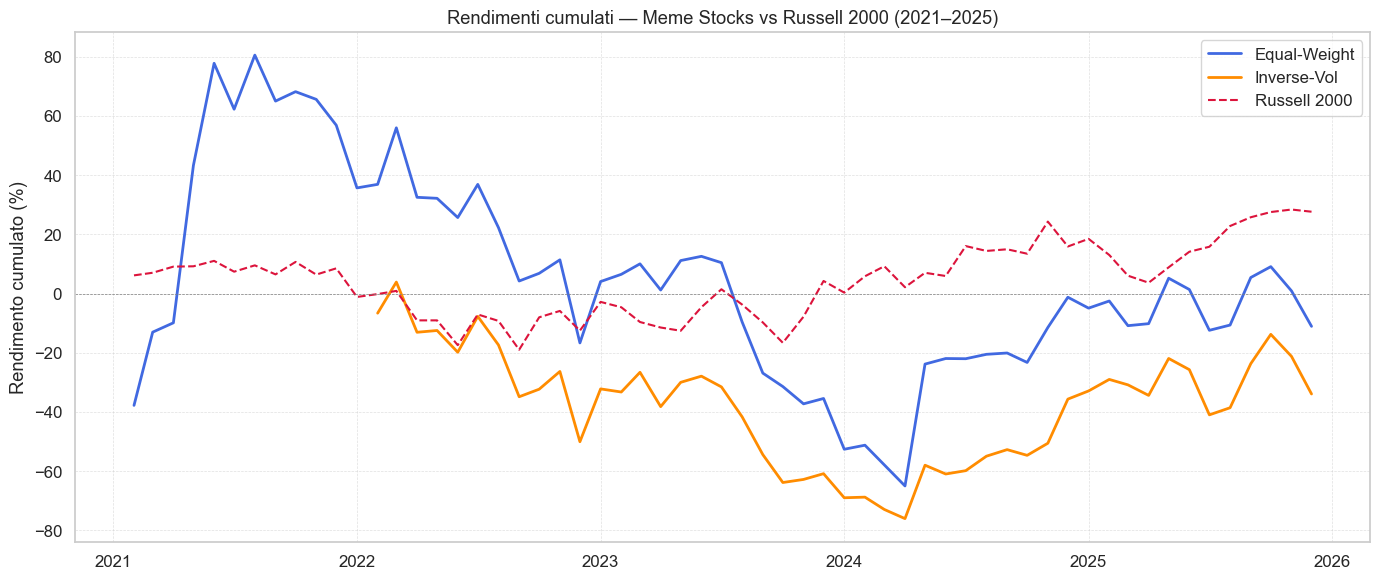

In [47]:
# Rendimenti cumulati dei due portafogli e del benchmark a confronto
cum_ew  = ret_ew.cumsum()
cum_iv  = ret_iv.cumsum()
cum_rut = returns_rut.cumsum()

plt.figure(figsize=(14, 6))
plt.plot(cum_ew,  linewidth=2, color='royalblue', label='Equal-Weight')
plt.plot(cum_iv,  linewidth=2, color='darkorange', label='Inverse-Vol')
plt.plot(cum_rut, linewidth=1.5, color='crimson', linestyle='--', label='Russell 2000')
plt.axhline(0, color='gray', linewidth=0.5, linestyle='--')
plt.title('Rendimenti cumulati — Meme Stocks vs Russell 2000 (2021–2025)')
plt.ylabel('Rendimento cumulato (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Il grafico confronta i rendimenti cumulati dei due portafogli costruiti sulle meme stocks con il Russell 2000 come benchmark nel periodo gennaio 2021 – dicembre 2025.

Il portafoglio **Equal-Weight** (blu) parte in forte perdita a inizio 2021, prima che GME esploda, per poi toccare un picco di circa +80% nella fase speculativa di gennaio-febbraio 2021. Dopo il crollo successivo rimane volatile ma sostanzialmente intorno allo zero, chiudendo il periodo in territorio leggermente negativo.

Il portafoglio **Inverse-Vol** (arancione) mostra una performance nettamente peggiore: perde fino a quasi -80% nel 2024, riflettendo il fatto che il meccanismo inverse-vol tende a sovrappesare i titoli meno volatili nei periodi precedenti, che però continuano a deteriorarsi (BB, NOK, AMC).

Il **Russell 2000** (rosso tratteggiato) è l'unico a chiudere il periodo in territorio positivo (+30% circa), evidenziando come entrambe le strategie sulle meme stocks abbiano distrutto valore.

In [48]:
def metriche(ret_series, nome):
    r = ret_series.dropna() / 100
    return {
        'Portfolio':      nome,
        'CAGR (%)':       round(qs.stats.cagr(r, periods=12) * 100, 2),
        'Volatilità (%)': round(qs.stats.volatility(r, periods=12) * 100, 2),
        'Sharpe':         round(qs.stats.sharpe(r, periods=12), 3),
        'Sortino':        round(qs.stats.sortino(r, periods=12), 3),
        'Max DD (%)':     round(qs.stats.max_drawdown(r) * 100, 2)
    }

tab = pd.DataFrame([
    metriche(ret_ew,           'Equal-Weight'),
    metriche(ret_iv,           'Inverse-Vol'),
    metriche(returns_rut,      'Russell 2000')
]).set_index('Portfolio')

tab

,CAGR (%),Volatilità (%),Sharpe,Sortino,Max DD (%)
Portfolio,,,,,
Equal-Weight,-15.38,54.96,-0.041,-0.064,-82.29
Inverse-Vol,-13.31,33.28,-0.260,-0.347,-60.73
Russell 2000,3.72,20.03,0.281,0.436,-28.06
